In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import re
from pathlib import Path
from pandas.errors import EmptyDataError
from sklearn.preprocessing import OneHotEncoder


import src.preprocessing as pre
# import src.features as feat
# import src.modeling as mod

In [2]:
x = "/Users/arthur/Documents/data/ACP/Export_pupille_ACP_10_F_68ANS_Benson2_2024-01-10_13-23-59.csv"
df = pd.read_csv(x, sep=';', skiprows=21, encoding='latin-1').drop(columns=['Unnamed: 10', 'LX (deg)', 'LY (deg)',	'RX (deg)',	'RY (deg)'])

split = re.split(r'_| ', str(x))
df['condition'] = split[2]
df['id'] = split[3]

# df = df.drop(columns=['Time (ms)', 'Unnamed: 10'])
# data_all = pd.read_csv("/Users/arthu/Documents/Marseille/aMU/M1/Stage/2026_06_19_data1.csv", sep=',', encoding='latin-1')

In [4]:
df = pre.detect_blink(df, k=0.5, blink_shape=5)
df['RDX_smoothed'] = df['RDX (pix)'].rolling(window=10, win_type='gaussian').mean(std=2)
df = pre.dynamic_threshold(df, 7, 20)
df.loc[df['blinks']==1, ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)', 'RDX_smoothed']] = np.nan

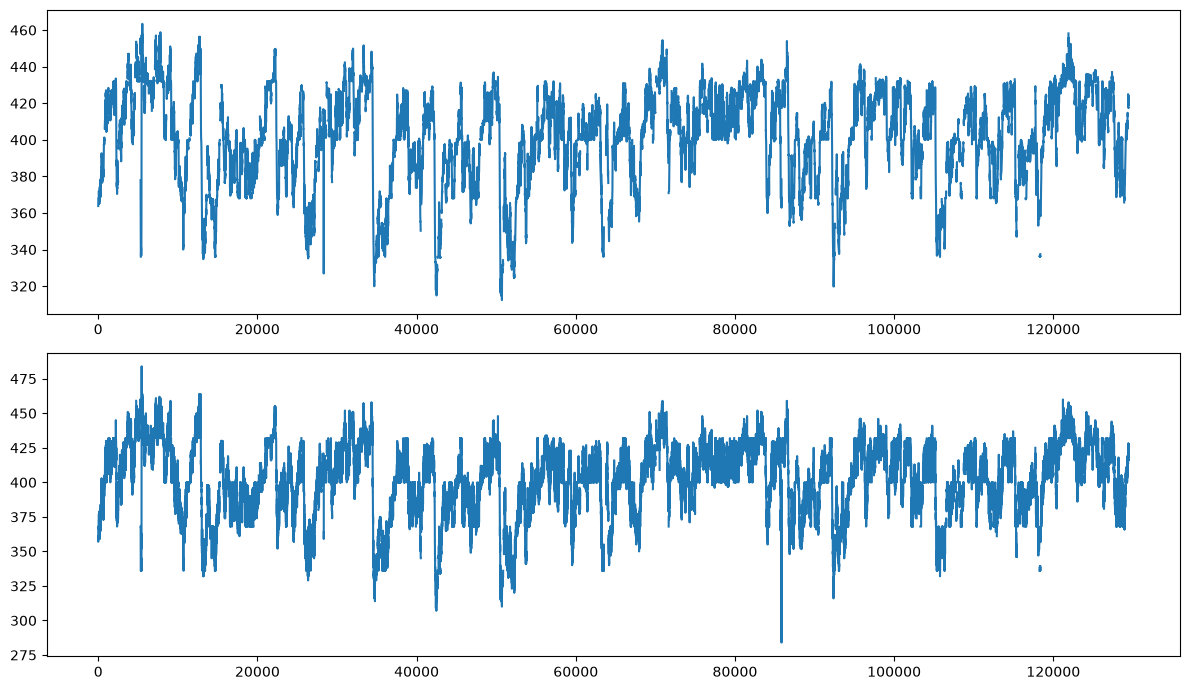

In [5]:
start = 0
stop = len(df)

fig, ax = plt.subplots(2, 1, figsize=(12, 7))

ax[0].plot(df.loc[start:stop, 'RDX_smoothed'])
ax[1].plot(df.loc[start:stop, 'RDX (pix)'])
# plt.axhline(t, c='r')
# plt.plot(df.loc[start:stop, 'M']*400, c='g')
# plt.plot(df.loc[start:stop, 'onset']*400, c='y')
# plt.plot(df.loc[start:stop, 'offset']*400, c='y')

plt.tight_layout()

In [5]:
# fill in the gaps
from scipy.ndimage import binary_closing

blink_binary = df['M'].values 
df['M'] = binary_closing(blink_binary, structure=np.ones(5)).astype(int)

In [6]:
# identify onsets and offsets
df['onset'] = (df['M'].diff() == 1).astype(int)
df['offset'] = (df['M'].diff() == -1).astype(int)

In [7]:
# smooth
df['smoothed'] = df['RDX (pix)'].rolling(window=10, win_type='gaussian').mean(std=2)

In [8]:
# dynamic threshold
# applying dynamic threshold to a 21ms window for onset and 21ms for offset

df['blinks'] = 0

onset_idx = df['onset'][df['onset']==1].index.values
offset_idx = df['offset'][df['offset']==1].index.values

onset_buffer = 7 # i.e 21ms
offset_buffer = 20 # i.e 60ms

for i in range(len(offset_idx)):
    #onset
    onset_pos = onset_idx[i]

    new_onset = df.loc[onset_pos-onset_buffer: onset_pos, 'smoothed'].argmax()
    df.loc[onset_pos, 'onset'] = 0
    df.loc[onset_pos - (onset_buffer+new_onset), 'onset'] = 1

    #offset
    offset_pos = offset_idx[i]

    new_offset = df.loc[offset_pos: offset_pos+offset_buffer, 'smoothed'].argmax()
    df.loc[offset_pos, 'offset'] = 0
    df.loc[offset_pos + new_offset, 'offset'] = 1

    df.loc[(onset_pos - (onset_buffer+new_onset)): (offset_pos + new_offset), 'blinks'] = 1

In [9]:
# for i in blinks:
#     df.loc[i[0]:i[1], ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)', 'smoothed']] = np.nan

df.loc[df['blinks']==1, ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)', 'smoothed']] = np.nan

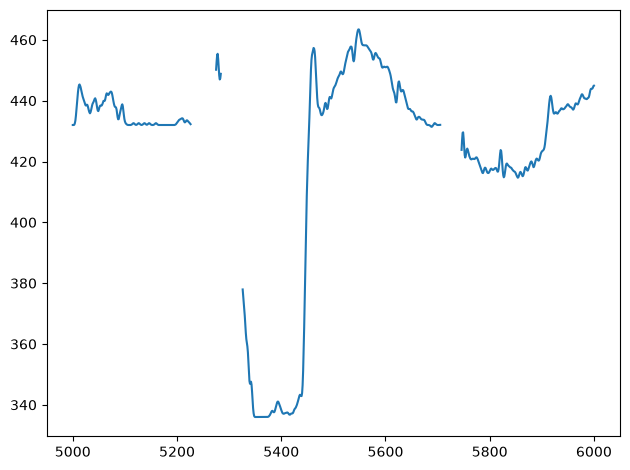

In [16]:
start = 5000
stop = 6000

plt.plot(df.loc[start:stop, 'smoothed'])
# plt.axhline(t, c='r')
# plt.plot(df.loc[start:stop, 'M']*400, c='g')
# plt.plot(df.loc[start:stop, 'onset']*400, c='y')
# plt.plot(df.loc[start:stop, 'offset']*400, c='y')

plt.tight_layout()

In [35]:
stim_windows, df = pre.extract_windows(df)
df

,Time (ms),LDX (pix),LDY (pix),RDX (pix),RDY (pix),Label,condition,id,M,onset,offset,smoothed,blinks,stim_window
0,2,400.0,363.0,361.0,355.0,consignes=on,ACP,10,0,0,0,NaN,0,0
1,5,400.0,363.0,359.0,352.0,NaN,ACP,10,0,0,0,NaN,0,0
2,8,400.0,375.0,361.0,357.0,NaN,ACP,10,0,0,0,NaN,0,0
3,12,400.0,368.0,357.0,355.0,NaN,ACP,10,0,0,0,NaN,0,0
4,15,400.0,370.0,361.0,364.0,NaN,ACP,10,0,0,0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129441,433099,453.0,384.0,418.0,365.0,NaN,ACP,10,0,0,0,420.259112,0,0
129442,433103,454.0,384.0,416.0,365.0,NaN,ACP,10,0,0,0,418.741020,0,0
129443,433106,457.0,387.0,421.0,365.0,NaN,ACP,10,0,0,0,417.801111,0,0
129444,433109,450.0,384.0,416.0,365.0,NaN,ACP,10,0,0,0,417.331913,0,0


In [11]:
x = "/Users/arthur/Documents/data/ACP/Export_pupille_ACP_10_F_68ANS_Benson2_2024-01-10_13-23-59.csv"
old_df = pd.read_csv(x, sep=';', skiprows=21, encoding='latin-1').drop(columns=['Unnamed: 10', 'LX (deg)', 'LY (deg)',	'RX (deg)',	'RY (deg)'])

split = re.split(r'_| ', str(x))
old_df['condition'] = split[2]
old_df['id'] = split[3]

In [12]:
columns = ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)']

stim_windows, old_df = pre.extract_windows(old_df)
order_stim, old_df = pre.extract_stim(old_df, stim_windows)
old_df = pre.detect_blink_pd(old_df)
df_blink_removed = pre.remove_blink_pd(old_df, 300, 60)
df_smoothed = pre.smooth(df_blink_removed, stim_windows, columns, lfreq=15)

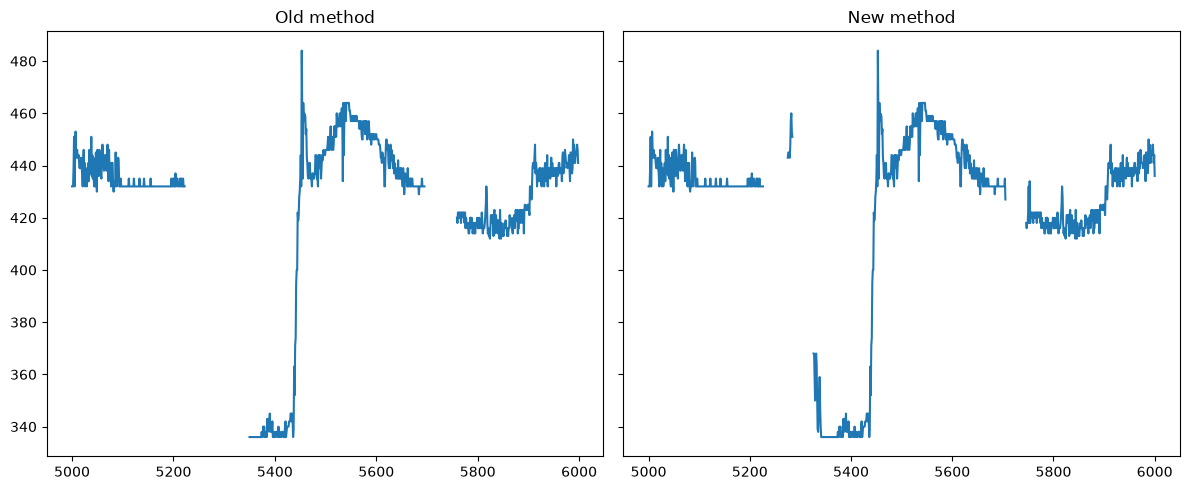

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

start = 5000
stop = 6000

ax[0].plot(df_blink_removed.loc[start:stop,'RDX (pix)'])
ax[1].plot(df.loc[start:stop,'RDX (pix)'])

ax[0].set_title('Old method')
ax[1].set_title('New method')


# plt.savefig('figures/old_new_method5.png')
plt.tight_layout()

In [ ]:
# indexes = df_blink_removed[df_blink_removed.trial==1].index.values

# sos = sp.signal.butter(5, Wn=15, fs=300, btype='low', output='sos')
# df_blink_removed.loc[indexes, 'RDY (pix)'] = sp.signal.sosfiltfilt(sos, df_blink_removed[df_blink_removed.trial==1]['RDY (pix)'])

In [ ]:
plt.plot(df_blink_removed[df_blink_removed.trial==18]['RDY (pix)'].rolling(20).mean())

In [ ]:
plt.plot(df[df.trial==18]['RDY (pix)'])

In [ ]:
plt.plot(df_blink_removed[df_blink_removed.trial==1]['RDY (pix)'].interpolate(method='linear'), c='r')
# plt.plot(df[df.trial==1]['RDY (pix)'].interpolate())

In [ ]:
indexes = df[df.blink==1.0].index.values.tolist()

for i in indexes:
    df.loc[i-30:i+30, 'RDY (pix)'] = np.nan

In [ ]:
x = df[df.trial==4]['RDY (pix)']
plt.plot(x)
# blink_mask = (df.trial==1) & (df.blink==1.0)
# plt.scatter(df[blink_mask].index, df[blink_mask]['RDY (pix)'], color='red', s=50)

In [ ]:
df['stim_window'].value_counts()

In [ ]:
current_dir = Path.cwd()
project_dir = current_dir.parent.parent
PCA_dir = project_dir / "data/ACP"
AMN_dir = project_dir / "data/AMN"
DFT_dir = project_dir / "data/DFT"
CTR_dir = project_dir / "data/CTR"

In [ ]:
# def smooth_explore(data, column, lfreq):
#     df_smooth = data.copy()
#     for trial in data['trial'].unique():
#         for col in column:
#             sos = sp.signal.butter(5, Wn=lfreq, fs=300, btype='low', output='sos')
#             df_smooth[df_smooth['trial']==trial].loc[:, col] = sp.signal.sosfiltfilt(sos, df_smooth[df_smooth['trial']==trial].loc[:, col])
#     return df_smooth

In [ ]:
def find_bad_signals_explore(data, stim_windows, column):
    removed = 0
    total = 0
    for col in column:
        data.loc[:, f'{col}_removed'] = 0
        for i, v in enumerate(stim_windows):
            # print(f'col: {col}, trial: {i}, max: {(pupil_diam.loc[v[0]:v[1], col].diff()/pupil_diam.loc[v[0]:v[1], 'time'].diff()).abs().max()}')
            if data.loc[v[0]:v[1], col].mean() > 0:
                data.loc[v[0]:v[1], f'{col}_removed']=1
                # data.loc[v[0]:v[1], col] = np.nan
            if (data.loc[v[0]:v[1], col].diff()/data.loc[v[0]:v[1], 'time'].diff()).abs().max() > 1500:
                data.loc[v[0]:v[1], f'{col}_removed']=1
                # data.loc[v[0]:v[1], col] = np.nan
            # if data.loc[v[0]:v[1], col].abs().max() > data.loc[v[0]:v[0]+800, col].abs().max()*1.15:
            #     data.loc[v[0]:v[1], f'{col}_removed']=1
            #     # data.loc[v[0]:v[1], col] = np.nan


    return data

In [33]:

# stim_windows, df = pre.extract_windows(df)
# order_stim, df = pre.extract_stim(df, stim_windows)
# df = pre.detect_blink_pd(df)
# df_blink_removed = pre.remove_blink_pd(df, 300, 60)


split = re.split(r'_| ', str(x))
columns = ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)']
stim_windows, df = pre.extract_windows(df)
order_stim, df = pre.extract_stim(df, stim_windows)

pupil_diam = pre.remove_blink(df.loc[:, columns], stim_windows)
pupil_diam = pre.add_stim_columns(pupil_diam, stim_windows, order_stim, trial_len=1792, sampling_rate=300)
pupil_diam = pre.smooth(pupil_diam, stim_windows, columns, lfreq=15)
pupil_diam = pre.baseline_correct(pupil_diam, stim_windows, columns)
pupil_diam = find_bad_signals_explore(pupil_diam, stim_windows, columns)
pupil_diam = pre.trials_only(pupil_diam)
pupil_diam['id'] = int(split[3])
pupil_diam = pre.remove_bad_signals(pupil_diam, columns, threshold=0.35)
pupil_diam = pre.one_hot_encoder(pupil_diam)
pupil_diam = pupil_diam.groupby(['valence', 'category', 'time']).mean().reset_index().drop(columns=['trial', 'valence', 'category'])

pupil_diam['condition'] = split[2]

In [ ]:
df

In [ ]:
stim_windows

### Model

In [ ]:
def model_fit(x, y):
    x = np.linspace(0, len(y)/300, len(y))
    gmodel = Model(mod.sim_func)
    params = gmodel.make_params()

    params['D_1'].set(value=250.0, min=0.0, max=2000)
    params['t_0'].set(value=0.3, min=0.0, max=6.0)
    params['tau_1'].set(value=1.0, min=0.01, max=50.0)
    params['tau_2'].set(value=0.8, min=0.01, max=50.0)
    
    result = gmodel.fit(y, params, t=x, D_0=y[0], weights=np.repeat([20.0, 0.2], [300, 1492]))

    # plt.plot(x, y, '-')
    # plt.plot(x, result.init_fit, '--', label='initial fit')
    # plt.plot(x, result.best_fit, '-', label='best fit')
    # plt.legend()
    # sns.despine()
    # plt.show()
    
    return result.best_values

In [ ]:
from lmfit import Model

x = np.linspace(0, 1792/300, 1792)
y = pupil_diam[(pupil_diam.valence=='negative') & (pupil_diam.category=='visage')]['RDX (pix)']

gmodel = Model(mod.sim_func)
params = gmodel.make_params()

params['D_1'].set(value=250.0, min=0.0)
params['t_0'].set(value=0.3, min=0.0)
params['tau_1'].set(value=1.0, min=0.0)
params['tau_2'].set(value=0.8, min=0.0)

result = gmodel.fit(y, params, t=x, D_0=y[0], weights=np.repeat([20.0, 0.2], [300, 1492]))

print(result.fit_report())

plt.plot(x, y, '-')
plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.legend()
sns.despine()
plt.show()

### Extract all parameters

In [ ]:
def extract_params(file, condition):
    column_names=['id', 'condition', 'valence', 'category', 'latency', 'mean_variation', 'max_diam', 'D_1', 't_0', 'tau_1', 'tau_2']
    data = pd.DataFrame(columns=column_names)
    for i, x in enumerate(file.iterdir()):
        # import data
        print(f'starting {i}')
        try:
            df = pd.read_csv(x, sep=';', skiprows=21, encoding='latin-1')
            split = re.split(r'_| ', str(x))
            id_pps = f'{split[2]}_{split[3]}'
            print(f'file: {x}, id: {id_pps}')
            columns = list(df.columns.values)[5:9]
            stim_windows = extract_windows(df)
            order_stim = extract_stim(df, stim_windows)

            pupil_diam = remove_blink(df.loc[:, columns], stim_windows)
            pupil_diam = add_stim_columns(pupil_diam, stim_windows, order_stim, trial_len=1792, freq=300)
            pupil_diam = smooth(pupil_diam, stim_windows, columns, lfreq=15)
            pupil_diam = baseline_correct(pupil_diam, stim_windows, columns)
            pupil_diam = remove_bad_signals(pupil_diam, stim_windows, columns)
            pupil_diam = trials_only(pupil_diam)

            unique_trials = pupil_diam.loc[:, 'trial'].drop_duplicates()

            for i in (unique_trials):
                c = pupil_diam.loc[:, 'category'][pupil_diam.loc[:, 'trial']==i].drop_duplicates().iloc[0]
                v = pupil_diam.loc[:, 'valence'][pupil_diam.loc[:, 'trial']==i].drop_duplicates().iloc[0]
                mean_pupil = mean(pupil_diam, category=c, valence=v, eye='RDX (pix)')
                params = model_fit(pupil_diam.loc[:, 'time'][pupil_diam['trial']==0], mean_pupil)
                data.loc[len(data)] = [id_pps, condition, v, c, latency(mean_pupil), mean_variation(mean_pupil), max_diam(mean_pupil), params['D_1'], params['t_0'], params['tau_1'], params['tau_2']]
                
        except EmptyDataError:
            print(x)

    return data

In [ ]:
def extract_timeseries(file, condition, threshold):
    new_columns=['valence', 'category', 'time', 'LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)', 'condition', 'id']
    columns = ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)']
    pps_data = pd.DataFrame(columns=new_columns)
    for i, x in enumerate(file.iterdir()):
        # import data
        print(f'starting {i}')
        try:        
            df = pd.read_csv(x, sep=';', skiprows=21, encoding='latin-1')
            # split = re.split(r'_| ', str(x))
            # id_pps = f'{split[2]}_{split[3]}'
            # print(f'file: {x}, id: {id_pps}')
            # columns = list(df.columns.values)[5:9]
            # stim_windows = extract_windows(df)
            # order_stim = extract_stim(df, stim_windows)

            # pupil_diam = remove_blink(df.loc[:, columns], stim_windows)
            # pupil_diam = add_stim_columns(pupil_diam, stim_windows, order_stim, trial_len=1792, freq=300)
            # pupil_diam = smooth(pupil_diam, stim_windows, columns, lfreq=15)
            # pupil_diam = baseline_correct(pupil_diam, stim_windows, columns)
            # pupil_diam = remove_bad_signals(pupil_diam, stim_windows, columns)

            # pupil_diam = pupil_diam.groupby(['valence', 'category', 'time']).mean().reset_index()
            # pps_data = pd.concat([pps_data, pupil_diam], ignore_index=True)

            stim_windows = extract_windows(df)
            order_stim = extract_stim(df, stim_windows)
            
            pupil_diam = remove_blink(df.loc[:, columns], stim_windows)
            pupil_diam = add_stim_columns(pupil_diam, stim_windows, order_stim, trial_len=1792, freq=300)
            pupil_diam = smooth(pupil_diam, stim_windows, columns, lfreq=15)
            pupil_diam = baseline_correct(pupil_diam, stim_windows, columns)
            pupil_diam = find_bad_signals_explore(pupil_diam, stim_windows, columns)
            pupil_diam = trials_only(pupil_diam)
            # pupil_diam = remove_bad_signals(pupil_diam, columns, threshold=0.35)
            # pupil_diam = pupil_diam.groupby(['valence', 'category', 'time']).mean().reset_index().drop(columns='trial')
            
            split = re.split(r'_| ', str(x))
            pupil_diam['condition'] = split[2]
            pupil_diam['id'] = int(split[3])

            pps_data = pd.concat([pps_data, pupil_diam], ignore_index=True)
            
        except EmptyDataError:
            print(x)

    pps_data = remove_bad_signals(pps_data, columns, threshold=threshold)
    return pps_data

In [ ]:
current_dir = Path.cwd()
project_dir = current_dir.parent.parent
PCA_dir = project_dir / "data/ACP"
AMN_dir = project_dir / "data/AMN"
DFT_dir = project_dir / "data/DFT"
CTR_dir = project_dir / "data/CTR"

In [ ]:
pca_data = extract_timeseries(PCA_dir, 'PCA', 0.5)
amn_data = extract_timeseries(AMN_dir, 'AMN', 0.5)
dft_data = extract_timeseries(DFT_dir, 'DFT', 0.5)
ctr_data = extract_timeseries(CTR_dir, 'CTR', 0.5)
all_data = pd.concat([pca_data, amn_data, dft_data, ctr_data], ignore_index=True)

In [ ]:
def normalise(data, param):
    mean = np.mean(data[param][(data['valence']=='neutre') & (data['condition']=='CTR')])
    std = np.std(data[param][(data['valence']=='neutre') & (data['condition']=='CTR')])
    data[f'{param}_zscore'] = (data[param] - mean)/std
    return data

In [ ]:
data_all['tau_2/tau_1'] = data_all['tau_2'] / data_all['tau_1']

In [ ]:
columns_to_normalise = list(data_all.columns.values)[6:]
for i in columns_to_normalise:
    data_all = normalise(data_all, i)

In [ ]:
from scipy.stats import mannwhitneyu
from statannotations.Annotator import Annotator
from itertools import combinations

In [ ]:
def plot_all_conditions(data, y, x, hue, test, letter, xlabel, ylabel):
    plotting_parameters = {
        'data': data,
        'x': x,
        'y': y,
        'hue': hue,
    }
    
    ax = sns.boxplot(**plotting_parameters, gap=.1, showfliers=False)

    cond = np.unique(data.loc[:, 'condition'])
    val = np.unique(data.loc[:, 'valence'])
    
    pair = []
    for i in cond:
        if len(val) == 1:
            pair.append(i)
        else:
            for j in val:
                pair.append((i, j))
    pairs = list(combinations(pair, r=2))
    
    annotator = Annotator(ax, pairs=pairs, **plotting_parameters)
    annotator.configure(test=test, hide_non_significant=True).apply_and_annotate()

    try:
        sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    except ValueError:
        pass

    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.text(-0.04, 1.05, letter, transform=ax.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')
    sns.despine()
    plt.tight_layout()
    plt.show()

### Expxloring data

In [ ]:
ax = sns.catplot(
    data=data_all,
    x='condition', y='t_0', hue='valence',
    col='category',
    kind='bar', gap=.1
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

In [ ]:
ax = sns.catplot(
    data=data_all,
    x='condition', y='tau_1', hue='valence',
    col='category',
    kind='bar', gap=.1
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

In [ ]:
ax = sns.catplot(
    data=data_all,
    x='condition', y='latency', hue='valence',
    col='category',
    kind='bar', gap=.1
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

In [ ]:
p1 = sns.relplot(
    data=final_series[final_series['category']=='visage'],
    x='time', y='time_series', hue='valence',
    col='cond_category',
    kind='line', errorbar=None, 
    height=4, aspect=1.5
)

p2 = sns.relplot(
    data=final_series[final_series['category']=='objet'],
    x='time', y='time_series', hue='valence',
    col='cond_category',
    kind='line', errorbar=None, 
    height=4, aspect=1.5
)

# ax1 = p1.axes[0]
# ax2 = p2.axes[0]



ax1_left = p1.axes[0, 0]   # First subplot (left)
ax1_right = p1.axes[0, 1]  # Second subplot (right)

ax2_left = p2.axes[0, 0]   # First subplot (left)
ax2_right = p2.axes[0, 1]  # Second subplot (right)

# Add text labels to each subplot
ax1_left.text(-0.05, 1.05, 'A', transform=ax1_left.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')
ax1_right.text(-0.05, 1.05, 'B', transform=ax1_right.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')

sns.move_legend(p1, "upper left", bbox_to_anchor=(1, 1))
p1.set(ylabel='Right eye horizontal diameter (pix)')
plt.tight_layout()

ax2_left.text(-0.05, 1.05, 'C', transform=ax2_left.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')
ax2_right.text(-0.05, 1.05, 'D', transform=ax2_right.transAxes, fontsize=13, fontweight='bold', va='top', ha='right')

sns.move_legend(p2, "upper left", bbox_to_anchor=(1, 1))
p2.set(ylabel='Right eye horizontal diameter (pix)')
plt.tight_layout()

ax1_left.set_title("AMN, DFT and PCA")
ax1_right.set_title("Control")
ax2_left.set_title("AMN, DFT and PCA")
ax2_right.set_title("Control")
plt.tight_layout()

p1.fig.suptitle('Object', y=1.08)
p2.fig.suptitle('Face', y=1.08)
plt.tight_layout

p1.fig.savefig('Object.png', dpi=600, bbox_inches='tight')
p2.fig.savefig('Face.png', dpi=600, bbox_inches='tight')

In [ ]:
sns.relplot(final_series, x='time', y='time_series', col='condition', row='category', hue='valence', kind='line', height=4)
plt.tight_layout()

In [ ]:
# all_timeseries = all_timeseries.drop(columns='trial')
# b = all_timeseries.groupby(['valence', 'category', 'condition', 'time']).mean().reset_index()
# b.to_csv('2026_06_23_data_timeseries.csv', index=False)

In [ ]:
g = sns.lineplot(timeseries[timeseries['condition']=='AMN'], x='time', y='RDX (pix)', hue='valence', style='category', errorbar=None)
g.axhline(y=-10.838777)

In [ ]:
min_curve = timeseries.groupby(['valence', 'category', 'condition']).min().reset_index().drop(columns='time')
max_curve = timeseries[(timeseries['time']>1) & (timeseries['time']<5.9)].groupby(['valence', 'category', 'condition']).max().reset_index().drop(columns='time')

In [ ]:
ratio = min_curve.copy()
for i in ratio.columns.values:
    if isinstance(ratio[i][0], float):
        ratio[f'{i}_ratio'] = max_curve[i]/min_curve[i]

In [ ]:
g = sns.catplot(
    data=ratio, x="valence", y="LDX (pix)_ratio", hue="condition",
    capsize=.2, kind="point", height=5, aspect=1.5, errorbar=None
)
g.despine()
g.set(ylabel='ratio of maximum to minimum pupil diameter (RDX)')
plt.tight_layout()

In [ ]:
timeseries.groupby(['valence', 'category', 'condition']).mean().reset_index().drop(columns='time')

In [ ]:
all_data = pd.read_csv('/Users/arthu/Documents/Marseille/aMU/M1/Stage/2026_07_03_data_timeseries.csv').drop(columns='trial')

In [ ]:
data = all_data.groupby(['id', 'condition', 'valence', 'category', 'time']).mean().reset_index()

In [ ]:
data_min = data[(data.time >= 0.5)& (data.time <= 2.0)].groupby(['condition', 'valence', 'category']).min().reset_index().drop(columns=['time'])
data_max = data[(data.time >= 2.0)& (data.time <= 5.5)].groupby(['condition', 'valence', 'category']).max().reset_index().drop(columns=['time'])
data_dif = data_min.loc[:, ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)']]-data_max.loc[:, ['LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)']]
data_dif[['id', 'condition', 'valence', 'category']] = data_min[['id', 'condition', 'valence', 'category']]

In [ ]:
g = sns.catplot(
    data=data_dif, x="valence", y="RDX (pix)", hue="condition",
    capsize=.2, kind="point", height=5, aspect=1.5, errorbar=None
)
g.despine()
plt.tight_layout()

In [ ]:
data
sns.relplot(data, x='time', y='RDX (pix)', col='condition', row='category', hue='valence', errorbar=None, kind='line')

In [ ]:
ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
ohetransform = ohe.fit_transform(df[['category', 'valence', 'condition']])
data = pd.concat([df, ohetransform], axis=1).drop(columns=['category', 'valence', 'condition'])


In [ ]:
missing_values = {
    'ACP': data[data.condition_ACP==1.0]['RDX (pix)'].isna().mean(),
    'DFT': data[data.condition_AMN==1.0]['RDX (pix)'].isna().mean(),
    'AMN': data[data.condition_DFT==1.0]['RDX (pix)'].isna().mean(),
    'CTR': data[data.condition_CTR==1.0]['RDX (pix)'].isna().mean()
}


sns.barplot(data = missing_values, orient='h')
plt.tight_layout()

In [ ]:
test = data[(data.category_visage==1.0) & (data.valence_neutre==1.0) & (data.id==40)].groupby('time').mean()['RDX (pix)']

plt.plot(test, c='r')
plt.plot(test.rolling(30).mean())
plt.tight_layout()